# Exercise 04


# Part 1 - Linear Regression

Estimate a regression using the Income data


## Forecast of income

We'll be working with a dataset from US Census indome ([data dictionary](https://archive.ics.uci.edu/ml/datasets/Adult)).

Many businesses would like to personalize their offer based on customer’s income. High-income customers could be, for instance, exposed to premium products. As a customer’s income is not always explicitly known, predictive model could estimate income of a person based on other information.

Our goal is to create a predictive model that will be able to output an estimation of a person income.

In [2]:
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

# read the data and set the datetime as the index
income = pd.read_csv('https://github.com/albahnsen/PracticalMachineLearningClass/raw/master/datasets/income.csv.zip', index_col=0)

income.head()

,Age,Workclass,fnlwgt,Education,Education-Num,Martial Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,51806.0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,68719.0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,51255.0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,47398.0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,30493.0


In [3]:
income.shape

(32561, 15)

# Exercise 4.1 

What is the relation between the age and Income?

For a one percent increase in the Age how much the income increases?

Using sklearn estimate a linear regression and predict the income when the Age is 30 and 40 years

<Axes: xlabel='Age', ylabel='Income'>

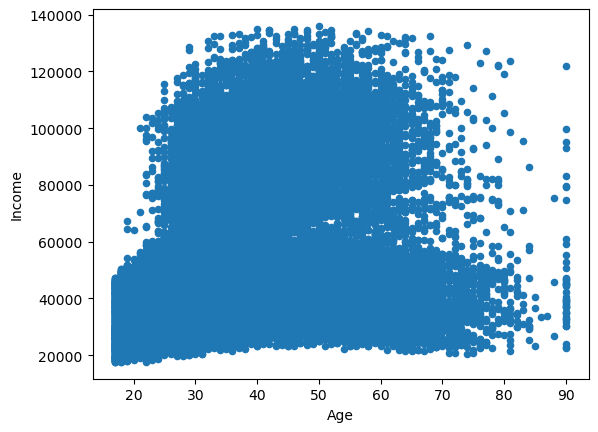

In [4]:
income.plot(x='Age', y='Income', kind='scatter')

In [ ]:
y = income["Income"].to_numpy().reshape(-1, 1)
X = income["Age"].to_numpy()

In [18]:
n_samples = X.shape[0]
X_ = np.c_[np.ones(n_samples), X]
X_

array([[ 1., 39.],
       [ 1., 50.],
       [ 1., 38.],
       ...,
       [ 1., 58.],
       [ 1., 22.],
       [ 1., 52.]], shape=(32561, 2))

In [1]:
from sklearn.linear_model import LinearRegression

In [5]:
linreg1 = LinearRegression(fit_intercept=False)

In [19]:
linreg1.fit(X_, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
linreg1.coef_

array([[32538.08813087,   542.16765707]])

From the coefficients, an increase by `1` of age results in an increase by `542` of income.

In [21]:
# income = b + w_1 * age
linreg1.coef_[0,0] + linreg1.coef_[0,1] * 38

np.float64(53140.459099619475)

In [ ]:
# income = b + w_1 * age
linreg1.coef_[0,0] + linreg1.coef_[0,1] * 39

np.float64(53682.62675669187)

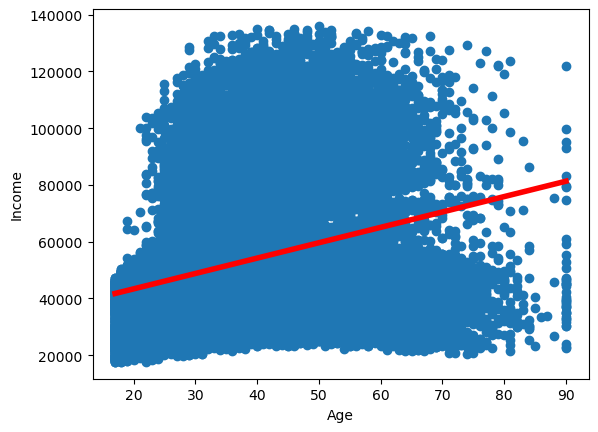

In [29]:
def lr_predict(ws, X):
    return np.dot(ws, X.T).reshape(-1,1)

plt.scatter(X, y)

x = np.c_[np.ones(2), [X.max(), X.min()]]
plt.plot(x[:,1], lr_predict(linreg1.coef_, x), "r", lw=4)
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

Making prediction for people at age 30 and 40.

In [33]:
linreg1.predict(np.c_[np.ones(2), [30, 40]])

array([[48803.11784304],
       [54224.79441376]])

# Exercise 4.2
Evaluate the model using the MSE

In [35]:
from sklearn import metrics

y_predict = linreg1.predict(X_)

print("MSE: ", metrics.mean_squared_error(y, y_predict))
print("MAE: ", metrics.mean_absolute_error(y, y_predict))

MSE:  593783043.8402297
MAE:  19027.654313997285



# Exercise 4.3

Run a regression model using as features the Age and Age$^2$ using the OLS equations

$$ W = (X^T X)^{-1} X^T Y $$

In [41]:
income["Age2"] = income["Age"] ** 2
new_X = income[["Age", "Age2"]].to_numpy()
new_X_ = np.hstack((np.ones(n_samples).reshape(-1,1), new_X))

W = np.dot(np.linalg.inv(np.dot(new_X_.T, new_X_)), np.dot(new_X_.T, y))
W

array([[-16225.07097408],
       [  3131.77014151],
       [   -30.54341041]])

Making prediction for people at the age of 30 and 40.

In [42]:
lr_predict(W.reshape(-1), np.c_[[1,1], [30, 40], [30**2, 40**2]])

array([[50238.96390027],
       [60176.27802692]])

Calculation MAE and MSE.

In [43]:
new_y_predict = lr_predict(W.reshape(-1), new_X_)

print("MAE: ", metrics.mean_absolute_error(y, new_y_predict))
print("MSE: ", metrics.mean_squared_error(y, new_y_predict))

MAE:  18462.15170142762
MSE:  544646260.781817


Look like we are making some progress, I guess?

# Exercise 4.4


Estimate a regression using more features.

How is the performance compared to using only the Age?

In [64]:
income["Sex label"] = np.where(income["Sex"] == "Male", 1, 0)

occupation_map_table = {val: label for label, val in enumerate(income["Occupation"].unique())}
income["Occupation label"] = income["Occupation"].map(occupation_map_table)

In [66]:
income.head()

,Age,Workclass,fnlwgt,Education,Education-Num,Martial Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,Income,Age2,Sex label,Occupation label
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,51806.0,1521,1,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,68719.0,2500,1,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,51255.0,1444,1,2
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,47398.0,2809,1,2
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,30493.0,784,0,3


In [ ]:
# View correlation matrix
income[["Age", "Education-Num", "Sex label", "Hours per week", "Occupation label", "Income"]].corr()

,Age,Education-Num,Sex label,Hours per week,Occupation label,Income
Age,1.000000,0.036527,0.088832,0.068756,0.017201,0.290408
Education-Num,0.036527,1.000000,0.012280,0.148123,-0.242997,0.430757
Sex label,0.088832,0.012280,1.000000,0.229309,0.147779,0.435144
Hours per week,0.068756,0.148123,0.229309,1.000000,-0.045240,0.283949
Occupation label,0.017201,-0.242997,0.147779,-0.045240,1.000000,-0.088098
Income,0.290408,0.430757,0.435144,0.283949,-0.088098,1.000000


In [68]:
features = ["Age", "Education-Num", "Sex label", "Hours per week"]

linreg2 = LinearRegression()
linreg2.fit(income[features], income["Income"])

y_predict = linreg2.predict(income[features])
print("MAE: ", metrics.mean_absolute_error(y, y_predict))
print("MSE: ", metrics.mean_squared_error(y, y_predict))

MAE:  14665.331140628878
MSE:  362846537.0347183


In [69]:
features = ["Age", "Education-Num", "Sex label", "Hours per week", "Occupation label"]

linreg2 = LinearRegression()
linreg2.fit(income[features], income["Income"])

y_predict = linreg2.predict(income[features])
print("MAE: ", metrics.mean_absolute_error(y, y_predict))
print("MSE: ", metrics.mean_squared_error(y, y_predict))

MAE:  14643.375235753483
MSE:  361352184.2076036


We can see that, features with higher correlation make signification decrease to the error. While adding one more inrellevant feature, occupation feature, does not make much impact.

# Part 2: Logistic Regression

### Customer Churn: 
losing/attrition of the customers from the company. Especially, the industries that the user acquisition is costly, it is crucially important for one company to reduce and ideally make the customer churn to 0 to sustain their recurring revenue. If you consider customer retention is always cheaper than customer acquisition and generally depends on the data of the user(usage of the service or product), it poses a great/exciting/hard problem for machine learning.

### Data
Dataset is from a telecom service provider where they have the service usage(international plan, voicemail plan, usage in daytime, usage in evenings and nights and so on) and basic demographic information(state and area code) of the user. For labels, I have a single data point whether the customer is churned out or not.


In [101]:
# Download the dataset
data = pd.read_csv('https://github.com/ghuiber/churn/raw/master/data/churn.csv')

In [102]:
data.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


# Exercise 4.5

Create Y and X

What is the distribution of the churners?

Split the data in train (70%) and test (30%)


## 4.5.1. Explore data

In [103]:
data.columns

Index(['State', 'Account Length', 'Area Code', 'Phone', 'Int'l Plan',
       'VMail Plan', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge',
       'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls',
       'Night Charge', 'Intl Mins', 'Intl Calls', 'Intl Charge',
       'CustServ Calls', 'Churn?'],
      dtype='str')

In [104]:
data["Churn?"].value_counts()

Churn?
False.    2850
True.      483
Name: count, dtype: int64

This seems like an imbalance dataset. For such classification problem, we need to consider the evaluation metrics for choosing a threshold.

## 4.5.1 Normalize data

When creating a model with multiple features, the values of each feature should span roughly the same range. If one feature's values range from 500 to 100,000 and another feature's values range from 2 to 12, the model will need to have weights of extremely low or extremely high values to be able to combine these features effectively. This could result in a low quality model. To avoid this, normalize features in a multi-feature model.

This can be done by converting each raw value to its Z-score. The **Z-score** for a given value is how many standard deviations away from the mean the value is.

In [110]:
feature_mean = data.mean(numeric_only=True)
feature_std = data.std(numeric_only=True)
numerical_columns = data.select_dtypes("number").columns

norm_data = (data[numerical_columns] - feature_mean) / feature_std
norm_data.head()

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
0,0.676388,-0.523525,1.234697,1.566532,0.476572,1.566801,-0.070599,-0.055932,-0.070416,0.866613,-0.465425,0.865899,-0.084995,-0.601105,-0.085678,-0.427868
1,0.149043,-0.523525,1.307752,-0.333688,1.124334,-0.333963,-0.108064,0.144845,-0.107533,1.058412,0.147802,1.059231,1.240296,-0.601105,1.240982,-0.427868
2,0.902393,-0.523525,-0.591671,1.168128,0.675883,1.168289,-1.573147,0.496204,-1.573664,-0.756756,0.198905,-0.755457,0.703015,0.211502,0.697052,-1.188040
3,-0.428526,-0.688731,-0.591671,2.196267,-1.466716,2.196429,-2.742453,-0.608068,-2.742856,-0.078539,-0.567629,-0.078794,-1.302831,1.024109,-1.306205,0.332305
4,-0.654531,-0.523525,-0.591671,-0.240054,0.626055,-0.240005,-1.038776,1.098534,-1.037784,-0.276270,1.067643,-0.276520,-0.049177,-0.601105,-0.045878,1.092477


In [111]:
norm_data.describe()

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
count,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03
mean,1.449652e-16,3.506879e-16,5.329603e-17,7.312216e-16,-2.025249e-16,-2.888645e-16,-7.248261e-17,3.293695e-16,1.321742e-16,7.887813e-17,-5.116419e-17,-4.476867e-17,-3.528198e-16,-4.476867e-17,2.771394e-16,7.461445e-18
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.512795e+00,-6.887309e-01,-5.916711e-01,-3.300601e+00,-5.004496e+00,-3.300667e+00,-3.963027e+00,-5.025157e+00,-3.963085e+00,-3.513121e+00,-3.429355e+00,-3.514838e+00,-3.666863e+00,-1.820015e+00,-3.667660e+00,-1.188040e+00
25%,-6.796428e-01,-6.887309e-01,-5.916711e-01,-6.623247e-01,-6.694697e-01,-6.622766e-01,-6.779283e-01,-6.582622e-01,-6.782106e-01,-6.697540e-01,-6.698335e-01,-6.675790e-01,-6.222756e-01,-6.011049e-01,-6.163417e-01,-4.278678e-01
50%,-1.627400e-03,-5.235247e-01,-5.916711e-01,-6.886644e-03,2.812069e-02,-6.729054e-03,8.274899e-03,-5.737769e-03,8.458004e-03,6.484830e-03,-5.504263e-03,4.690538e-03,2.246056e-02,-1.948014e-01,2.045516e-02,-4.278678e-01
75%,6.512763e-01,1.718559e+00,8.694238e-01,6.724189e-01,6.758832e-01,6.725781e-01,6.767314e-01,6.969809e-01,6.765680e-01,6.807464e-01,6.588250e-01,6.813540e-01,6.671967e-01,6.178056e-01,6.705186e-01,3.323046e-01
max,3.564231e+00,1.718559e+00,3.134121e+00,3.139950e+00,3.217105e+00,3.140331e+00,3.208584e+00,3.507855e+00,3.207498e+00,3.838505e+00,3.827165e+00,3.836188e+00,3.496872e+00,6.306055e+00,3.496304e+00,5.653511e+00


In [112]:
# Normalize binary category data to numeric data
norm_data["churn-label"] = data["Churn?"].map({"False.": 0, "True.": 1})

## 4.5.3. Select features

In [108]:
# Testing some features with the correlation matrix
test_fts = ["Account Length", "Area Code", "VMail Message", 'CustServ Calls', 'Night Mins', 'Night Calls', 'Night Charge', "churn-label"]
norm_data[test_fts].corr()

,Account Length,Area Code,VMail Message,CustServ Calls,Night Mins,Night Calls,Night Charge,churn-label
Account Length,1.000000,-0.012463,-0.004628,-0.003796,-0.008955,-0.013176,-0.008960,0.016541
Area Code,-0.012463,1.000000,-0.001994,0.027572,-0.005825,0.016522,-0.005845,0.006174
VMail Message,-0.004628,-0.001994,1.000000,-0.013263,0.007681,0.007123,0.007663,-0.089728
CustServ Calls,-0.003796,0.027572,-0.013263,1.000000,-0.009288,-0.012802,-0.009277,0.208750
Night Mins,-0.008955,-0.005825,0.007681,-0.009288,1.000000,0.011204,0.999999,0.035493
Night Calls,-0.013176,0.016522,0.007123,-0.012802,0.011204,1.000000,0.011188,0.006141
Night Charge,-0.008960,-0.005845,0.007663,-0.009277,0.999999,0.011188,1.000000,0.035496
churn-label,0.016541,0.006174,-0.089728,0.208750,0.035493,0.006141,0.035496,1.000000


Some features, e.g. area code and number of night calls, do not show much correlation with the churn rate. For this experiment, however, we will keep all numerical features for our model. Feature engineering will be discussed in future topics.

In [117]:
# split the index: train 70%, test 30%
n_samples = norm_data.shape[0]
split_index = round(n_samples * 0.7)

# shuffle data
data_shuffle = norm_data.sample(frac=1, random_state=0)

# split data
train_data = data_shuffle.iloc[:split_index]
test_data = data_shuffle.iloc[split_index:]

features = [ft for ft in data_shuffle.columns if ft != "churn-label"]

train_X = train_data[features]
train_y = train_data["churn-label"]

test_X = test_data[features]
test_y = test_data["churn-label"]

In [118]:
train_X.head()

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
405,-0.227633,-0.523525,-0.591671,1.551844,-0.470158,1.551681,-0.790324,0.747175,-0.789562,-0.044925,-1.385265,-0.043643,-0.335726,0.211502,-0.337743,-1.188040
118,0.274601,1.718559,2.038300,-1.213113,0.825367,-1.213066,-0.857366,-0.909233,-0.856837,-0.460160,0.914336,-0.461065,-0.084995,-0.601105,-0.085678,0.332305
710,-0.805201,1.718559,-0.591671,0.285031,-1.516544,0.284865,0.309968,0.395816,0.310035,1.167164,0.965439,1.169079,0.810471,-0.194801,0.816451,1.092477
499,-0.152297,-0.523525,-0.591671,-0.083997,-0.470158,-0.084488,0.856170,0.446010,0.855195,-2.473058,-0.261016,-2.473480,-0.980462,-1.007408,-0.974540,-0.427868
2594,0.349936,1.718559,-0.591671,3.038973,-0.968437,3.038813,0.047712,0.295427,0.047895,0.328786,0.352211,0.329841,0.559741,1.430413,0.564386,-0.427868


In [120]:
train_y.head()

405     0
118     0
710     0
499     0
2594    1
Name: churn-label, dtype: int64

# Exercise 4.6

Train a Logistic Regression using the training set and apply the algorithm to the testing set.

In [121]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(train_X, train_y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [122]:
print("Train (log) loss: ", metrics.log_loss(train_y, logreg.predict(train_X)))
print("Test (log) loss: ", metrics.log_loss(test_y, logreg.predict(test_X)))

Train (log) loss:  5.005633818291452
Test (log) loss:  5.298417048200221


# Exercise 4.7

a) Create a confusion matrix using the prediction on the 30% set.

b) Estimate the accuracy of the model in the 30% set


In [ ]:
test_y_predict_proba = logreg.predict_proba(test_X)

In [ ]:
test_y_predict_proba[0]

array([0.95214787, 0.04785213])

In [130]:
test_y[0]

np.int64(0)

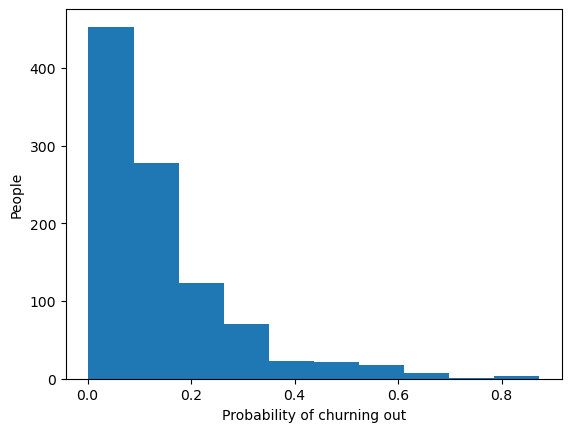

In [ ]:
plt.hist(test_y_predict_proba[:, 1])
plt.xlabel("Probability of churning out")
plt.ylabel("People")
plt.show()

In [136]:
test_y_predict = logreg.predict(test_X)

In [141]:
cm = metrics.confusion_matrix(test_y, test_y_predict)
cm

array([[832,  18],
       [129,  21]])

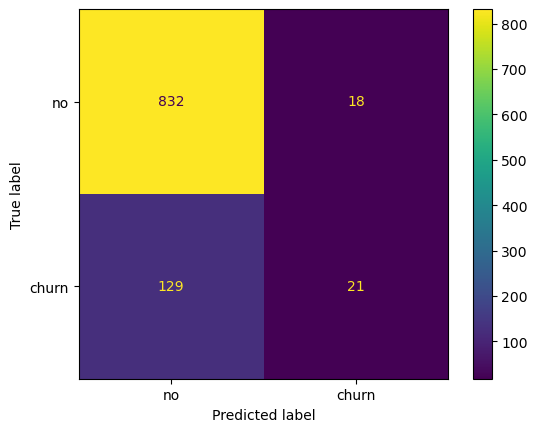

In [ ]:
dis_cm = metrics.ConfusionMatrixDisplay(cm, display_labels=["no", "churn"])
dis_cm.plot()

In our problem, customer acquisition is costly while customer retention is cheaper. Therefore, we wanted to predict if a customer may churn out or not. It is crucial that we did not miss any customer that might churn out, the model raising false alarm is easy to handle because customer retention is cheaper than losing a customer.

False negative error is costly.

In [145]:
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
print("Accuracy: ", accuracy)

Accuracy:  0.853


In [146]:
logreg.score(test_X, test_y)

0.853

The model scores 85.3% of accuracy while being useless because the dataset is imbalanced, with only 14.5% of the data recorded people churning out. An alternative metric would be "Recall" which is more sensitive to false negative error.

In [149]:
recall = cm[1,1] / (cm[1,1] + cm[1,0])
print("Recall: ", recall)

Recall:  0.14


From the metric Recall, we can see that the model is below the accepted level.